In [1]:
# Setup for Google Colab (optional)
import sys
if 'google.colab' in sys.modules:
    print("Running in Google Colab")
    # Install required packages
    !pip install -q py4DSTEM hyperspy scikit-image matplotlib numpy scipy
    
    # Clone the repository to access data
    !git clone -q https://github.com/NU-MSE-LECTURES/465-WINTER2026.git
    import os
    os.chdir('/content/465-WINTER2026')
    
    # Set up file handling
    from google.colab import files
    print("Colab setup complete!")
else:
    print("Running in local environment")

Running in local environment


<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_02/assignments/assignment_02_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 02: 4D-STEM Foundations

Complete this assignment to demonstrate your understanding of 4D-STEM data analysis and calibration.


In [2]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab. Installing requirements...")
    !pip install hyperspy ase py4DSTEM
    !git clone https://github.com/NU-MSE-LECTURES/465_Computational_Microscopy_2026.git
    print("Setup complete.")
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab.")

Not running in Google Colab.


## Task 1: Distinguish Navigation vs. Signal Axes

In your notebook, define the "Navigation Axes" (where the measurement is made, e.g., x, y scan positions).

Define the "Signal Axes" (what is measured at each point, e.g., an EELS spectrum or a 2D diffraction pattern).

Use signal.axes manager to print and verify the dimensionality of a 4D-STEM dataset (expected: 2 Navigation, 2 Signal).

In [4]:
# Your code here
import hyperspy.api as hs

si_sige = hs.load('C:/Users/wkddk/matsci465/Si-SiGe.dm4')
s = si_sige.transpose(navigation_axes=[2,3],signal_axes=[0,1]) # the navigation and signal axes in this dataset need to be swapped

s.axes_manager.navigation_axes[0].name = 'Rx'
s.axes_manager.navigation_axes[1].name = 'Ry'

s.axes_manager.signal_axes[0].name = 'Qx'
s.axes_manager.signal_axes[1].name = 'Qy'

s.axes_manager

Navigation axis name,size,index,offset,scale,units
Rx,17,0,0.0,2.0,nm
Ry,77,0,0.0,2.0,nm
Signal axis name,size,,offset,scale,units
Qx,448,,0.0,0.06208537146449089,1/nm
Qy,480,,0.0,0.06208537146449089,1/nm


## Task 2: Load and Calibrate 4D-STEM Data

Use py4DSTEM.io.read to load a 4D-STEM dataset (e.g., .dm4 or .h5).

**Note:** The dataset Si-SiGe.dm4 should be available in the raw_data folder.

Set the scan step size (real space calibration) using dataset.set_scan_step_size().

Perform Center of Mass (CoM) correction using dataset.get_diffraction_shifts() to center the unscattered beam.

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import py4DSTEM as p4
print(f'py4DSTEM version: {p4.__version__}') # running on Python 3.11

py4DSTEM version: 0.14.0


In [87]:
sige_datacube = p4.io.import_file('C:/Users/wkddk/matsci465/Si-SiGe.dm4')
sige = sige_datacube.swap_RQ() # like before, the navigation and signal axes need to be swapped
sige.shape

(77, 17, 480, 448)

In [88]:
# these values were taken from the Hyperspy axis manager
sige.calibration.set_Q_pixel_size(0.06208537146449089*0.1)
sige.calibration.set_Q_pixel_units('A^-1')
sige.calibration.set_R_pixel_size(2.0)
sige.calibration.set_R_pixel_units('nm')
sige.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:    0.006208537146449089
             R_pixel_size:    2.0
             Q_pixel_units:   A^-1
             R_pixel_units:   nm
)

In [91]:
Rpix = sige.calibration.get_R_pixel_size()
Qpix = sige.calibration.get_Q_pixel_size()

sige.set_dim(0, [0, Rpix], units='nm', name="Rx")
sige.set_dim(1, [0, Rpix], units='nm', name="Ry")
sige.set_dim(2, (np.arange(480) - 240) * Qpix, units='A^-1', name="Qx")
sige.set_dim(3, (np.arange(448) - 224) * Qpix, units='A^-1', name="Qy")
sige

DataCube( A 4-dimensional array of shape (77, 17, 480, 448) called 'dm_dataset',
          with dimensions:

              Rx = [0.0,2.0,...] nm
              Ry = [0.0,2.0,...] nm
              Qx = [-1.4900489151477814,-1.4838403780013323,...] A^-1
              Qy = [-1.390712320804596,-1.3845037836581469,...] A^-1

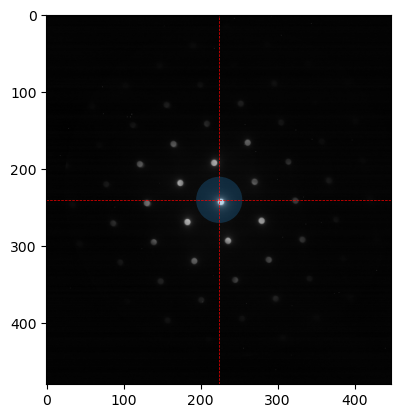

In [93]:
# sanity check
from matplotlib.patches import Circle

mean_dp = sige.data.mean(axis=(0,1))

fig, ax = plt.subplots(1, 1)

ax.imshow(np.log1p(mean_dp.data),cmap='gray')
ax.axhline(y=240,color='r',linestyle='--',linewidth=0.5)
ax.axvline(x=224,color='r',linestyle='--',linewidth=0.5)
mask = Circle((224,240), radius=30, alpha=0.3)
ax.add_patch(mask)

In [73]:
def circular_mask(shape, center, radius):
    yy, xx = np.indices(shape)
    cx, cy = center
    r2 = (xx - cx)**2 + (yy - cy)**2
    return r2 <= radius**2


def beam_center_masked_com(dp, radius):
    h, w = dp.shape
    approx_center = (w/2, h/2)
    mask = circular_mask(dp.shape, approx_center, radius)
    dp_masked = dp * mask
    cy, cx = center_of_mass(dp_masked)  # returns (row, col)
    return (cx, cy)

In [74]:
from scipy.ndimage import center_of_mass, shift

sige_CoM = np.zeros(shape=(sige.data.shape[0], sige.data.shape[1], 2))

for i in range(sige.data.shape[0]):
    for j in range(sige.data.shape[1]):
        sige_CoM[i,j,1], sige_CoM[i,j,0] = beam_center_masked_com(sige.data[i,j,:,:], 30)

ref_CoM = center_of_mass(mean_dp.data)

In [75]:
print(f'Reference CoM: {ref_CoM}')
print(f'Select CoM from one point: {sige_CoM[32,16,:]}')

Reference CoM: (239.7202052508977, 223.63286667158408)
Select CoM from one point: [242.21790653 225.67707957]


In [76]:
sige_calib = np.empty(shape=(sige.data.shape[0],sige.data.shape[1],sige.data.shape[2],sige.data.shape[3]))
shift_values = np.empty(shape=(sige.data.shape[0],sige.data.shape[1],2))

for i in range(sige.data.shape[0]):
    for j in range(sige.data.shape[1]):
        y_shift = ref_CoM[0] - sige_CoM[i,j,0]
        x_shift = ref_CoM[1] - sige_CoM[i,j,1]
        shift_values[i,j,:] = [y_shift, x_shift]
        sige_calib[i,j,:,:] = shift(sige.data[i,j,:,:], shift=(x_shift, y_shift), order=1, mode='nearest', prefilter=False)

Text(0.5, 1.0, 'Calibrated DP (example)')

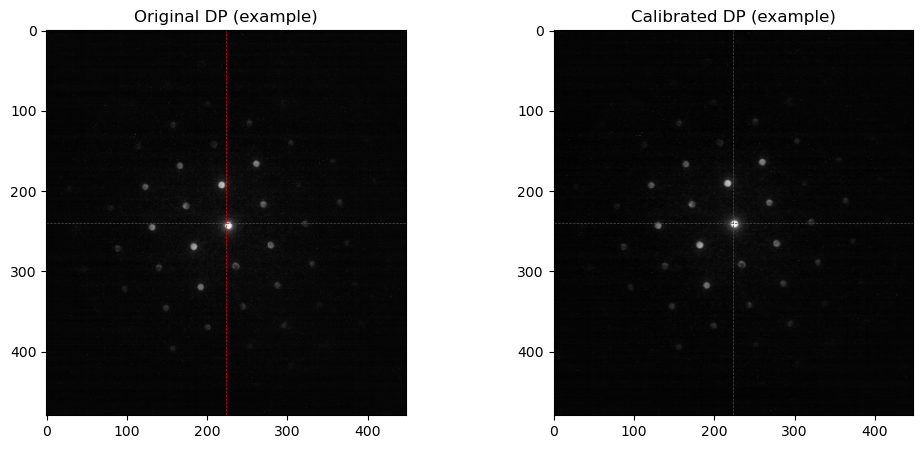

In [77]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].imshow(np.log1p(sige.data[32,16,:,:]),cmap='gray')
ax[0].axhline(y=ref_CoM[0],color='r',linestyle='--',linewidth=0.5)
ax[0].axvline(x=ref_CoM[1],color='r',linestyle='--',linewidth=0.5)
ax[0].set_title('Original DP (example)')

ax[1].imshow(np.log1p(sige_calib[32,16,:,:]),cmap='gray')
ax[1].axhline(y=ref_CoM[0],color='r',linestyle='--',linewidth=0.5)
ax[1].axvline(x=ref_CoM[1],color='r',linestyle='--',linewidth=0.5)
ax[1].set_title('Calibrated DP (example)')

In [80]:
sige_shifted = sige
sige_shifted.data = sige_calib

## Task 3: Virtual Detector Reconstruction

Generate a Virtual Bright Field (BF) image by integrating the central transmitted disk.

Generate an Annular Dark Field (ADF) image by integrating the scattered electrons in an outer ring.

Compare the Z-contrast in the ADF image to the diffraction contrast in the BF image.

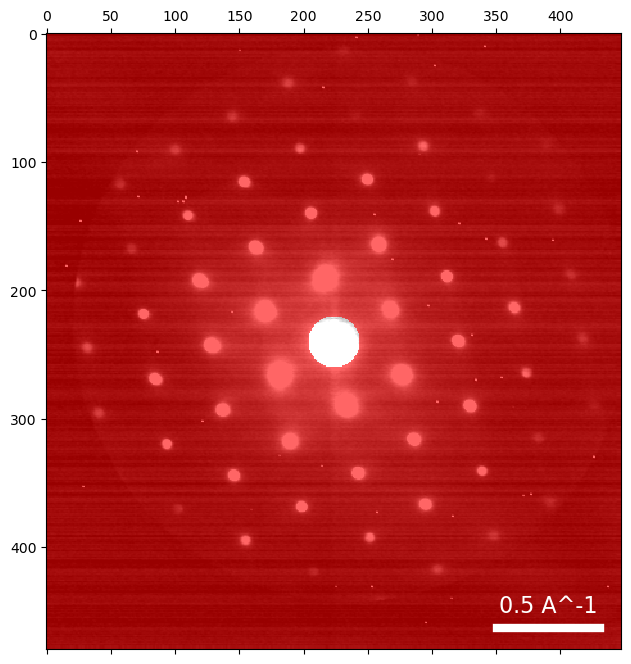

100%|████████████████████████████████████████████████████████████████████████████| 1309/1309 [00:00<00:00, 1866.56it/s]


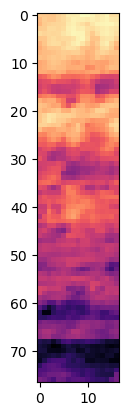

In [82]:
center = (240, 224)
radius = 20

sige_shifted.get_dp_mean()
sige_shifted.position_detector(mode = 'circle', geometry = (center, radius))
virtual_BF_img = sige_shifted.get_virtual_image(mode = 'circle', geometry = (center, radius), name = 'bright_field')
plt.imshow(virtual_BF_img.data, cmap='magma')

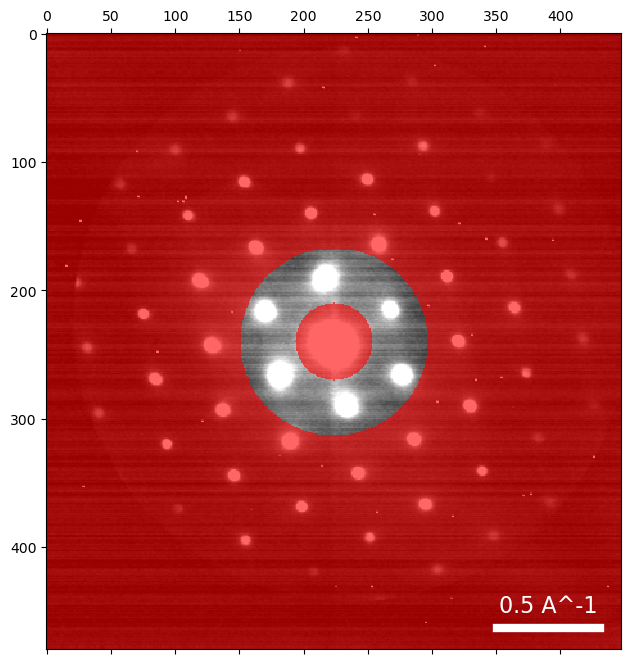

100%|████████████████████████████████████████████████████████████████████████████| 1309/1309 [00:00<00:00, 1623.79it/s]


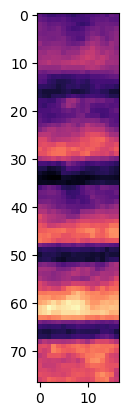

In [83]:
radii = (30,73)

sige_shifted.get_dp_mean()
sige_shifted.position_detector(mode = 'annular', geometry = (center, radii))
virtual_img = sige_shifted.get_virtual_image(mode = 'annulus', geometry = ((center),radii), name = 'dark_field')
plt.imshow(virtual_img.data,cmap='magma')

## Task 4: Basic 4D-STEM Visualization

Launch the interactive 4D-STEM browser using dataset.show() (if using a local GUI) or py4D.show_image().

Export a publication-quality figure of a virtual ADF image with a scale bar and a perceptually uniform colormap (e.g., magma).

In [2]:
# Your code here




from matplotlib.patches import Rectangle
if scale_bar_pixels < adf_image.shape[1] - 5:
    # Position scale bar in bottom-left corner
    bar_x, bar_y = 2, adf_image.shape[0] - 4
    scale_bar = Rectangle((bar_x, bar_y), scale_bar_pixels, 1, fill=True, color='white', linewidth=1)
    ax.add_patch(scale_bar)
    ax.text(bar_x + scale_bar_pixels/2, bar_y - 1, f'{scale_bar_length} nm', ha='center', va='top', 
            color='white', fontsize=10, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Integrated Intensity (a.u.)', fontsize=12)

plt.tight_layout()
plt.savefig('virtual_adf_figure_sisige.png', dpi=300, bbox_inches='tight')
plt.show()

## Task 5: Finalize and Submit

Update your README.md with a brief explanation of how virtual detectors allow post-acquisition imaging.

Push the completed Week 02 notebook to your GitHub repository.

Submit the repository link on Canvas.

In [ ]:
# Your code here